In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

# RNN Model Design (Time series)

## 실습 : Stock prediction


### **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

### **DataSet**

##### Load

In [4]:
# https://github.com/FinanceData/FinanceDataReader
%%capture
!pip install finance-datareader

In [5]:
import FinanceDataReader as fdr
#pd_data = fdr.DataReader('KS11', '2000-01-01') # KOSPI
# Samsung(005930), 1992-01-01 ~ 2018-10-31
pd_data = fdr.DataReader('005930', '2015-01-01')
# (Open,High,Low,Close,Volume,change)
pd_data = pd_data.drop(columns=['Change'])
print(pd_data.head())
print(pd_data.tail())

             Open   High    Low  Close  Volume
Date                                          
2015-01-02  26799  26799  26540  26600  175499
2015-01-05  26720  26720  26260  26660  202790
2015-01-06  26300  26340  25760  25900  304710
2015-01-07  25880  26220  25640  26140  286455
2015-01-08  26780  26780  26199  26280  289552
              Open    High     Low   Close    Volume
Date                                                
2025-10-24   97900   99000   97700   98800  18801925
2025-10-27  101300  102000  100600  102000  22169970
2025-10-28  100900  101000   99100   99500  20002282
2025-10-29  100200  101000   99100  100500  20899788
2025-10-30  102400  105800  102000  104100  15563244


#### Preprocessing

In [6]:
# 최대,최소값으로 정규화 하기
def MinMaxScaler(data):
    numerator = data - np.min(data, 0)
    denominator = (np.max(data, 0) - np.min(data, 0)) + 1e-7
    return numerator/denominator

In [7]:
xy = np.array(pd_data)  # np <- pandas data format
## 필요시 reordering
#xy = xy[::-1]          # 과거부터로 정렬 (chronically ordered)
xy = MinMaxScaler(xy)   # minmax 정규화
XX = xy                  # input data(Open,High,Low,Close,Volume)
YY = xy[:, [3]]          # 종가만 slicing -> target data

# data type 확인
print ("SHAPE OF X IS %s" % (XX.shape,))
print ("SHAPE OF Y IS %s" % (YY.shape,))

SHAPE OF X IS (2658, 5)
SHAPE OF Y IS (2658, 1)


In [8]:
# sequence generator
def seq_gen(x,seq_length):
    dataX = []
    dataY = []
    for i in range(0, len(x) - seq_length):
        _x = x[i:i + seq_length] # 7일치 데이터
        _y = x[i+seq_length:i+seq_length+1,3]   # 다음날 종가
        dataX.append(_x)
        dataY.append(_y)
    # train data : test data = 9 : 1
    train_size = int(len(dataY) * 0.9)
    test_size  = len(dataY) - train_size
    x_train = np.array(dataX[0:train_size]).copy()
    y_train = np.array(dataY[0:train_size]).copy()
    x_test  = np.array(dataX[train_size:]).copy()
    y_test  = np.array(dataY[train_size:]).copy()
    return x_train,y_train,x_test,y_test

In [9]:
## x:7일치 데이터, y:8일차 종가
timesteps = seq_length = 7
x_train,y_train,x_test,y_test = seq_gen(XX,seq_length)
ps(x_train,'x_train')
ps(y_train,'y_train')
ps(x_test,'x_test')
ps(y_test,'y_test')

[x_train] Shape(2385, 7, 5)
[y_train] Shape(2385, 1)
[x_test] Shape(266, 7, 5)
[y_test] Shape(266, 1)


In [10]:
hidden_dim = 10
data_dim  = x_train.shape[2]
data_dim #input_features = data_dim = 5

5

In [11]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        super().__init__()
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return torch.FloatTensor(self.x[idx]),torch.FloatTensor(self.y[idx])

In [12]:
batch_size = 64 ##

trainDataset = CustomDataset(x_train, y_train)
testDataset = CustomDataset(x_test, y_test)
trainDataLoader = DataLoader(trainDataset, batch_size, shuffle=True) # defalut : drop_last=False
testDataLoader = DataLoader(testDataset, batch_size, shuffle=False)

### Model Define

#### Basic RNN  

In [13]:
class Wrap_regression(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.mse_loss(y_pred, y)
        mape = FM.mean_absolute_percentage_error(y_pred, y)
        metrics={'loss':loss, 'mape':mape}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.mse_loss(y_pred, y)
        mape = FM.mean_absolute_percentage_error(y_pred, y)
        metrics={'val_loss':loss, 'val_mape':mape}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.005)

In [14]:
class BasicModel(Wrap_regression):
    def __init__(self, input_features, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_features, hidden_dim,
                            batch_first=True)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x[:, -1, :])
        return x

In [15]:
model_B = BasicModel(input_features=data_dim, hidden_dim=hidden_dim)
summary(model_B, input_size=(batch_size, timesteps, data_dim))

Layer (type:depth-idx)                   Output Shape              Param #
BasicModel                               [64, 1]                   --
├─LSTM: 1-1                              [64, 7, 10]               680
├─Linear: 1-2                            [64, 1]                   11
Total params: 691
Trainable params: 691
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.31
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05

In [16]:
model_B

BasicModel(
  (lstm): LSTM(5, 10, batch_first=True)
  (linear): Linear(in_features=10, out_features=1, bias=True)
)

#### Stacked RNN

In [17]:
class StackedModel(Wrap_regression):
    def __init__(self, input_features, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_features, hidden_dim,
#                            dropout=0.1, # 마지막을 제외하고 출력에 적용
                            num_layers=3, batch_first=True)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x[:, -1, :])
        return x

In [18]:
model_S = StackedModel(data_dim, hidden_dim)
summary(model_S, input_size=(batch_size, timesteps, data_dim))

Layer (type:depth-idx)                   Output Shape              Param #
StackedModel                             [64, 1]                   --
├─LSTM: 1-1                              [64, 7, 10]               2,440
├─Linear: 1-2                            [64, 1]                   11
Total params: 2,451
Trainable params: 2,451
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.09
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.01
Estimated Total Size (MB): 0.06

In [19]:
model_S

StackedModel(
  (lstm): LSTM(5, 10, num_layers=3, batch_first=True)
  (linear): Linear(in_features=10, out_features=1, bias=True)
)

### Training

https://pytorch-lightning.readthedocs.io/en/1.6.5/common/checkpointing.html

In [20]:
from lightning.pytorch.callbacks import ModelCheckpoint

In [21]:
%%time
model_B = BasicModel(data_dim, hidden_dim)
name = "model_B"

checkpoint_callback = ModelCheckpoint(dirpath='./aicamp', monitor='val_loss')
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger,callbacks=[checkpoint_callback])
trainer.fit(model_B, trainDataLoader, testDataLoader)

checkpoint = torch.load(checkpoint_callback.best_model_path)
model_B.load_state_dict(checkpoint['state_dict'])

model_B.eval()
# Wall time: 36.4 s

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more det

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (38) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


CPU times: user 24.8 s, sys: 551 ms, total: 25.3 s
Wall time: 25.7 s


BasicModel(
  (lstm): LSTM(5, 10, batch_first=True)
  (linear): Linear(in_features=10, out_features=1, bias=True)
)

Wall time: 36.4 s

In [22]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

In [23]:
%%time
model_S = StackedModel(data_dim, hidden_dim)
name = "model_S"

checkpoint_callback = ModelCheckpoint(dirpath='./aicamp', monitor='val_loss')
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger,callbacks=[checkpoint_callback])
trainer.fit(model_S, trainDataLoader, testDataLoader)

checkpoint = torch.load(checkpoint_callback.best_model_path)
model_S.load_state_dict(checkpoint['state_dict'])
model_S.eval()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /content/aicamp exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name   | Type   | Params | Mode 
------------------------------------------
0 | lstm   | LSTM   | 2.4 K  | train
1 | linear | Linear | 11     | train
------------------------------------------
2.5 K     Trainable params
0         Non-trainable params
2.5 K     Total params
0.010     Total estimated model params size (MB)
2

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (38) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


CPU times: user 27 s, sys: 392 ms, total: 27.4 s
Wall time: 27.1 s


StackedModel(
  (lstm): LSTM(5, 10, num_layers=3, batch_first=True)
  (linear): Linear(in_features=10, out_features=1, bias=True)
)

Wall time: 1min 28s

In [24]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df2 = history.groupby('epoch').last().drop('step', axis=1)

### **Analysis**

In [25]:
def plt_history(historys,names):
    mins =[]
    title_name = ""
    for i,h in enumerate(historys):
        title_name += f"({names[i]}:{min(h['val_mape'])*100:.3f})"
    plt.figure(figsize=(12,3))
    plt.subplot(131)
    for i,h in enumerate(historys):
        plt.plot(h['loss'], label=names[i])
    plt.title("Training loss")
    #plt.ylim(0.1, 1)
    plt.semilogy()
    plt.legend()
    plt.grid()

    plt.subplot(132)
    plt.title("validation loss")
    for i,h in enumerate(historys):
        plt.plot(h['val_loss'], label=names[i])
    #plt.ylim(0.1, 1)
    plt.semilogy()
    plt.legend()
    plt.grid()

    plt.subplot(133)
    plt.title(f"validation mape\n{title_name}")
    for i,h in enumerate(historys):
        plt.plot(h['val_mape'], label=names[i])
    #plt.ylim(0.1, 1)
    plt.semilogy()
    plt.legend()
    plt.grid()
    plt.show()

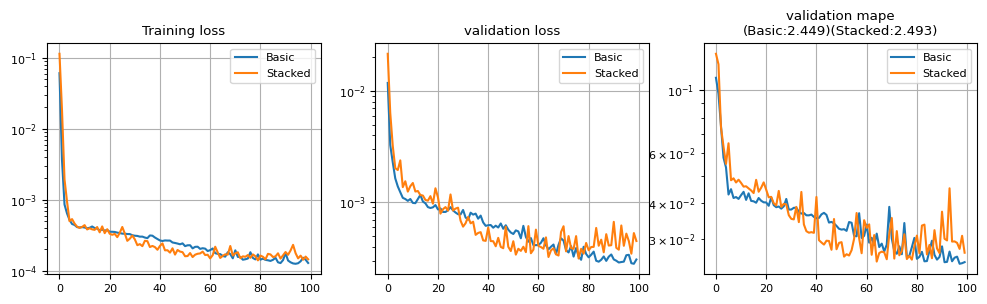

In [26]:
titles=["Basic","Stacked"]
plt_history([df,df2],titles)

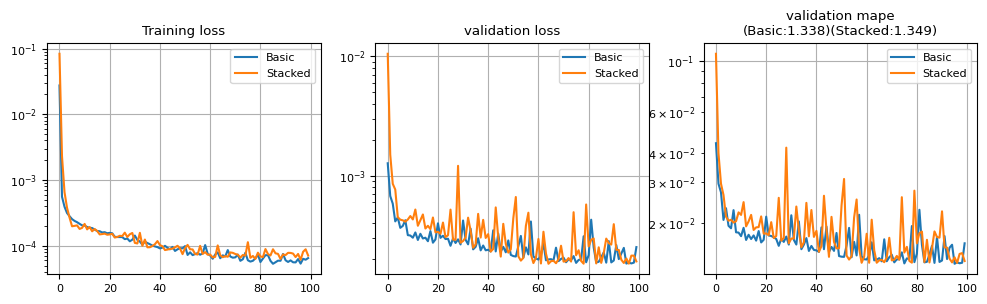

### Predict the stock price

In [27]:
history_n = ['Basic','Stacked']
colors=['green','blue','red']
def stock_plot(prices,title="",names=[]):
    plt.figure(figsize=(8, 4))
    for i, pred in enumerate(prices):
        plt.plot(pred,color=colors[i], label=names[i])
    plt.title(title)
    plt.xlabel('days')
    plt.ylabel('Normalized Stock Price')
    plt.legend()
    plt.grid()
    plt.show()
    return

def plot_predict(model,X,Y,title,names):
  pred_price_B = model_B(torch.Tensor(X)).detach().numpy()
  pred_price_o = model(torch.Tensor(X)).detach().numpy()
  stock_plot([Y[:,-1],pred_price_B[:,-1],pred_price_o[:,-1]],title,names)
  return

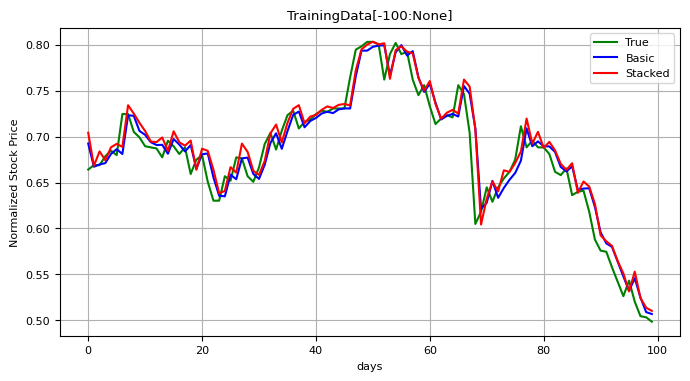

In [28]:
# Training data 마지막 100일
s_p = -100
e_p = None
X = x_train[s_p:e_p]
Y = y_train[s_p:e_p]

plot_predict(model_S,X,Y,title=f"TrainingData[{s_p}:{e_p}]",names=['True','Basic','Stacked'])

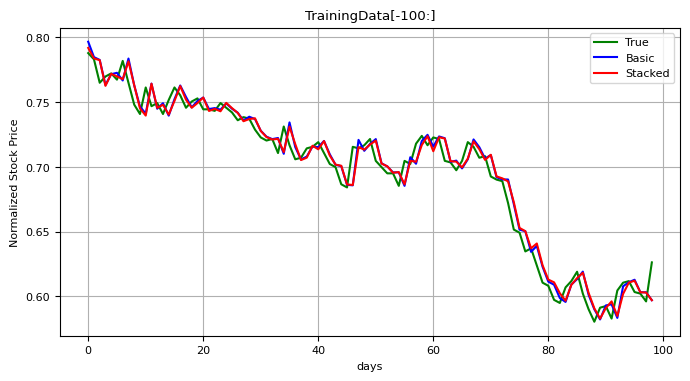

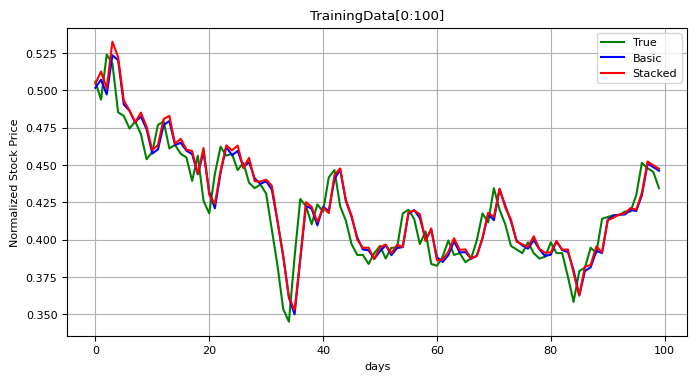

In [29]:
# Test 첫 100일
s_p = 0
e_p = 100
X = x_test[s_p:e_p]
Y = y_test[s_p:e_p]

plot_predict(model_S,X,Y,title=f"TrainingData[{s_p}:{e_p}]",names=['True','Basic','Stacked'])

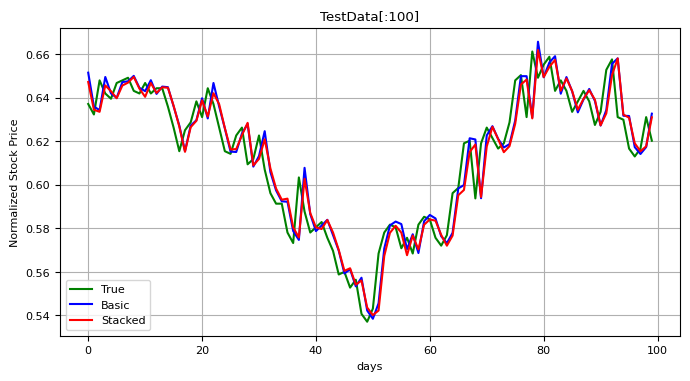

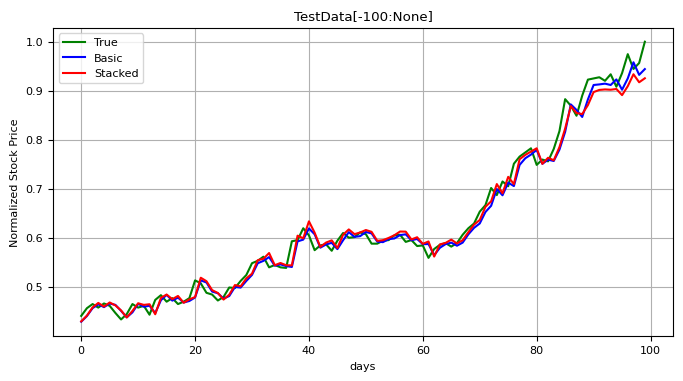

In [30]:
# Test 영역 마지막 100일
s_p = -100
e_p = None
X = x_test[s_p:e_p]
Y = y_test[s_p:e_p]

plot_predict(model_S,X,Y,title=f"TestData[{s_p}:{e_p}]",names=['True','Basic','Stacked'])

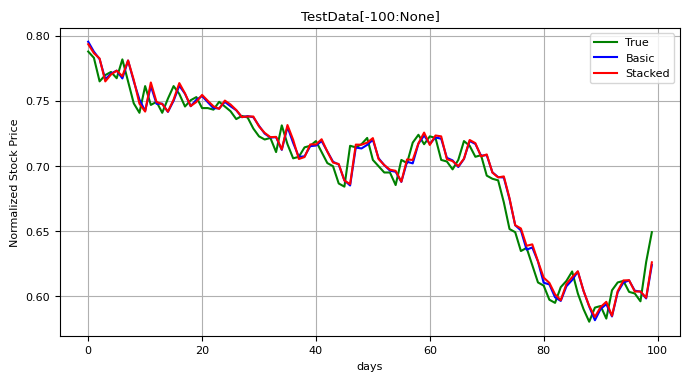

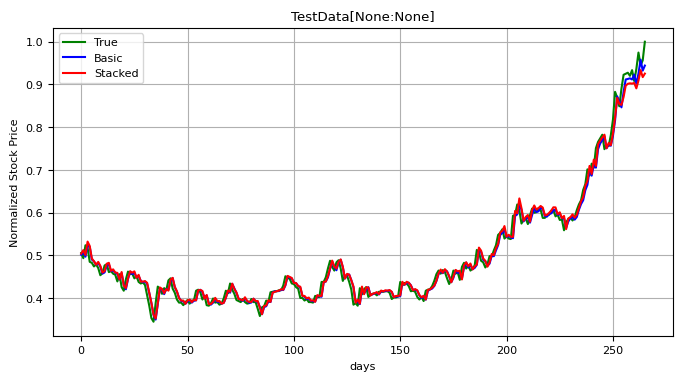

In [31]:
# Test 영역 전체
s_p = None
e_p = None
X = x_test[s_p:e_p]
Y = y_test[s_p:e_p]
plot_predict(model_S,X,Y,title=f"TestData[{s_p}:{e_p}]",names=['True','Basic','Stacked'])

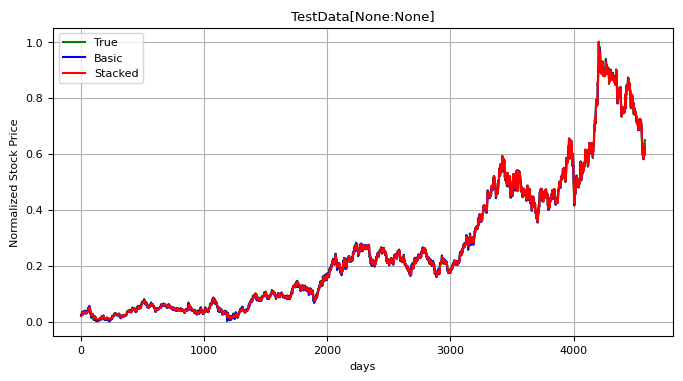

# **실습 과제**

## 과제 1. `timesteps = seq_length = 7`를 줄여보자
### -- model_B에서 5,3,1,14로 바꿔서 결과를 비교하자:

### **Seq. = 5**

In [32]:
timesteps = seq_length = 5
x_train,y_train,x_test,y_test = seq_gen(XX,seq_length)

trainDataset = CustomDataset(x_train, y_train)
testDataset = CustomDataset(x_test, y_test)
trainDataLoader = DataLoader(trainDataset, batch_size, shuffle=True) # defalut : drop_last=False
testDataLoader = DataLoader(testDataset, batch_size, shuffle=False)

ps(x_train,'x_train')
ps(y_train,'y_train')
ps(x_test,'x_test')
ps(y_test,'y_test')

[x_train] Shape(2387, 5, 5)
[y_train] Shape(2387, 1)
[x_test] Shape(266, 5, 5)
[y_test] Shape(266, 1)


In [33]:
%%time
model_B = BasicModel(data_dim, hidden_dim)
name = "model_B"

logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_B, trainDataLoader, testDataLoader)

v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfBs5 = history.groupby('epoch').last().drop('step', axis=1)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name   | Type   | Pa

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (38) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


CPU times: user 23.9 s, sys: 463 ms, total: 24.4 s
Wall time: 24.1 s


In [ ]:
titles=["Basic","Bs5"]
plt_history([df,dfBs5],titles)

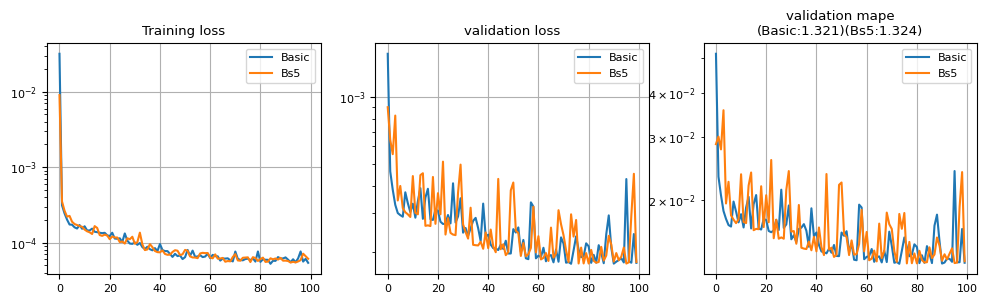

### **Seq. = 3**

In [ ]:
timesteps = seq_length = 3
x_train,y_train,x_test,y_test = seq_gen(XX,seq_length)

trainDataset = CustomDataset(x_train, y_train)
testDataset = CustomDataset(x_test, y_test)
trainDataLoader = DataLoader(trainDataset, batch_size, shuffle=True) # defalut : drop_last=False
testDataLoader = DataLoader(testDataset, batch_size, shuffle=False)

ps(x_train,'x_train')
ps(y_train,'y_train')
ps(x_test,'x_test')
ps(y_test,'y_test')

[x_train] Shape(2388, 3, 5)
[y_train] Shape(2388, 1)
[x_test] Shape(266, 3, 5)
[y_test] Shape(266, 1)


In [ ]:
%%time
model_B = BasicModel(data_dim, hidden_dim)
name = "model_B"

logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_B, trainDataLoader, testDataLoader)

v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfBs3 = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["Basic","Bs3"]
plt_history([df,dfBs3],titles)

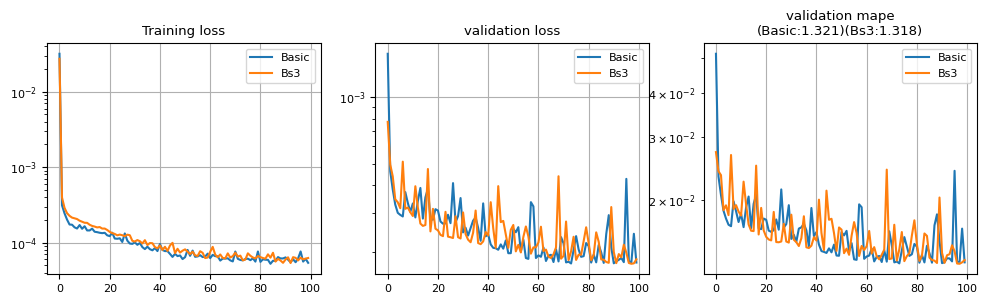

### **Seq. = 1**

In [ ]:
timesteps = seq_length = 1
x_train,y_train,x_test,y_test = seq_gen(XX,seq_length)

trainDataset = CustomDataset(x_train, y_train)
testDataset = CustomDataset(x_test, y_test)
trainDataLoader = DataLoader(trainDataset, batch_size, shuffle=True) # defalut : drop_last=False
testDataLoader = DataLoader(testDataset, batch_size, shuffle=False)

ps(x_train,'x_train')
ps(y_train,'y_train')
ps(x_test,'x_test')
ps(y_test,'y_test')

[x_train] Shape(2390, 1, 5)
[y_train] Shape(2390, 1)
[x_test] Shape(266, 1, 5)
[y_test] Shape(266, 1)


In [ ]:
%%time
model_B = BasicModel(data_dim, hidden_dim)
name = "model_B"

logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_B, trainDataLoader, testDataLoader)

v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfBs1 = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["Basic","Bs1"]
plt_history([df,dfBs1],titles)

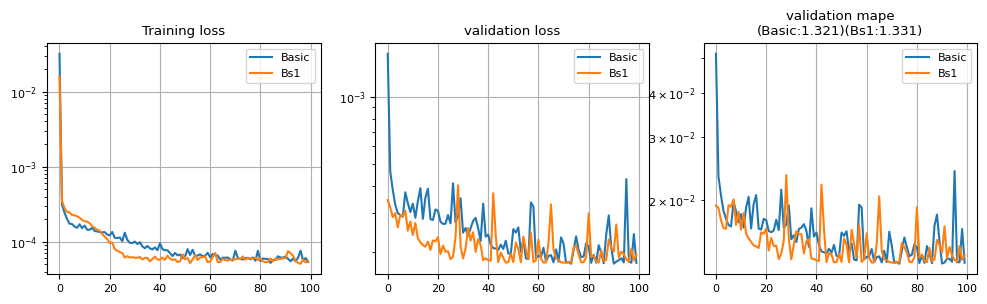

### **Seq. = 14**

In [ ]:
timesteps = seq_length = 14
x_train,y_train,x_test,y_test = seq_gen(XX,seq_length)

trainDataset = CustomDataset(x_train, y_train)
testDataset = CustomDataset(x_test, y_test)
trainDataLoader = DataLoader(trainDataset, batch_size, shuffle=True) # defalut : drop_last=False
testDataLoader = DataLoader(testDataset, batch_size, shuffle=False)

ps(x_train,'x_train')
ps(y_train,'y_train')
ps(x_test,'x_test')
ps(y_test,'y_test')

[x_train] Shape(2378, 14, 5)
[y_train] Shape(2378, 1)
[x_test] Shape(265, 14, 5)
[y_test] Shape(265, 1)


In [ ]:
%%time
model_B = BasicModel(data_dim, hidden_dim)
name = "model_B"

logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_B, trainDataLoader, testDataLoader)

v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfBs14 = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["Basic","Bs14"]
plt_history([df,dfBs14],titles)

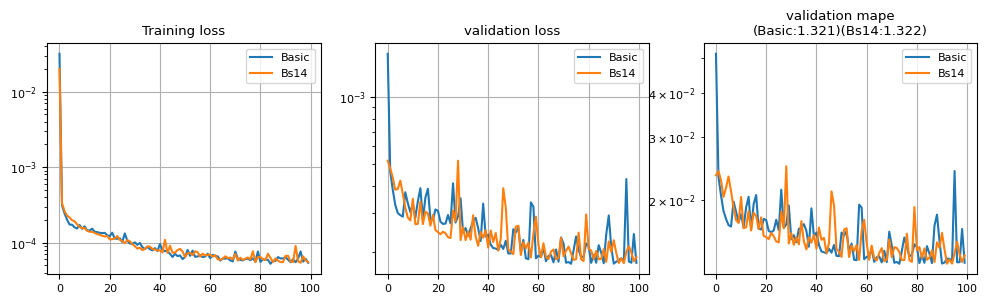

In [ ]:
# Mean without max values:1.24%

plt.figure(figsize=(5,2))
plt.plot([1,3,5,7,14],[1.331,1.318,1.324,1.321,1.322])
plt.plot([1,3,5,7,14],[1.433,1.432,1.429, 1.438, 1.428])
#plt.ylim(1.2,1.5)
plt.grid()
plt.show()

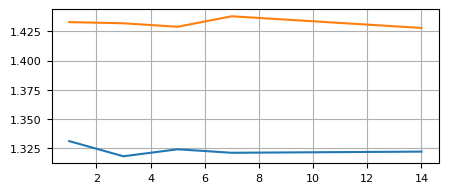

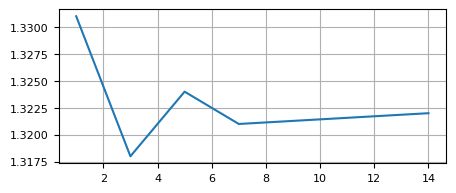

## 과제 2. model_S를 개선하여 model_S2를 만들어 보자
### -- 개선할 수 있는 부분을 생각해 보자
### -- LSTM layer 추가?
### -- Dense layer 추가?





In [ ]:
class StackedModel2(Wrap_regression):
    def __init__(self, input_features, hidden_dim):
        super().__init__()
        self.lstm = nn.Sequential(
            nn.Linear(input_features, hidden_dim*2),
            nn.Linear(hidden_dim*2, hidden_dim*2),  ####
            nn.LSTM(hidden_dim*2, hidden_dim, # dropout=0.1,
                    num_layers=2,                   ####
                    batch_first=True),)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x[:, -1, :])
        return x

In [ ]:
model_S2 = StackedModel2(data_dim, hidden_dim)
summary(model_S2, input_size=(batch_size, timesteps, data_dim))

Layer (type:depth-idx)                   Output Shape              Param #
StackedModel2                            [64, 1]                   --
├─Sequential: 1-1                        [64, 14, 10]              --
│    └─Linear: 2-1                       [64, 14, 20]              120
│    └─Linear: 2-2                       [64, 14, 20]              420
│    └─LSTM: 2-3                         [64, 14, 10]              2,160
├─Linear: 1-2                            [64, 1]                   11
Total params: 2,711
Trainable params: 2,711
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.97
Input size (MB): 0.02
Forward/backward pass size (MB): 0.36
Params size (MB): 0.01
Estimated Total Size (MB): 0.39

In [ ]:
timesteps = seq_length = 7
x_train,y_train,x_test,y_test = seq_gen(XX,seq_length)

trainDataset = CustomDataset(x_train, y_train)
testDataset = CustomDataset(x_test, y_test)
trainDataLoader = DataLoader(trainDataset, batch_size, shuffle=True) # defalut : drop_last=False
testDataLoader = DataLoader(testDataset, batch_size, shuffle=False)

ps(x_train,'x_train')
ps(y_train,'y_train')
ps(x_test,'x_test')
ps(y_test,'y_test')

[x_train] Shape(2385, 7, 5)
[y_train] Shape(2385, 1)
[x_test] Shape(265, 7, 5)
[y_test] Shape(265, 1)


In [ ]:
%%time
model_S2 = StackedModel2(data_dim, hidden_dim)
name = "model_S2"

checkpoint_callback = ModelCheckpoint(dirpath='./aicamp', monitor='val_loss')
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger,callbacks=[checkpoint_callback])
trainer.fit(model_S2, trainDataLoader, testDataLoader)

checkpoint = torch.load(checkpoint_callback.best_model_path)
model_S2.load_state_dict(checkpoint['state_dict'])
model_S2.eval()

Wall time: 36.4 s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfS2 = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["Stacked","Stacked2"]
plt_history([df2,dfS2],titles)

Dense layer 추가

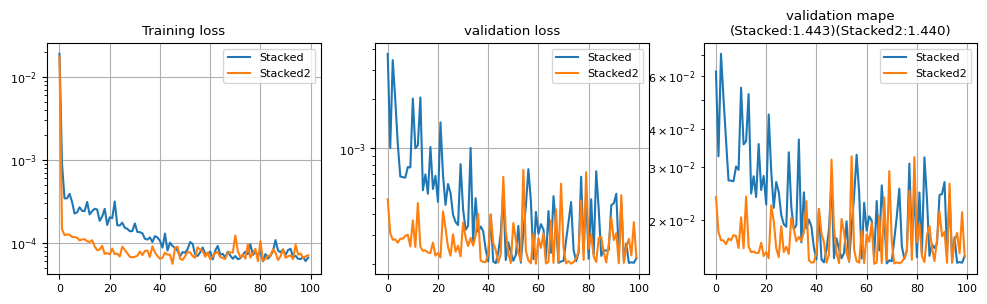

Dense + LSTM 추가

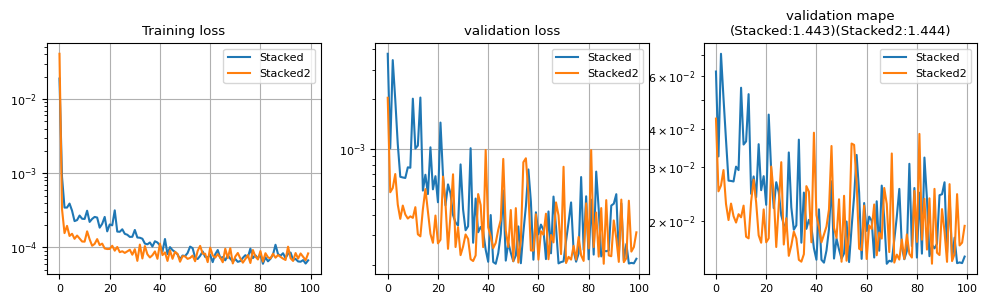

## 과제 3. LSTM을 Dense layer로 교체한 model을 만들어 보자
### -- 성능을 비교해 보자

In [ ]:
class DenseModel(Wrap_regression):
    def __init__(self, input_features,hidden_dim):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_features, hidden_dim*4),
            nn.ReLU(),
            nn.Linear(hidden_dim*4, 1) )

    def forward(self, x):
        x = self.linear(x)
        return x

In [ ]:
#input_features = x_train.shape[1]*x_train.shape[2] # 7*5

model_d = DenseModel(x_train.shape[1]*x_train.shape[2], hidden_dim)
summary(model_d, input_size=x_train[:batch_size].shape) #(64,7,5)

Layer (type:depth-idx)                   Output Shape              Param #
DenseModel                               [64, 1]                   --
├─Sequential: 1-1                        [64, 1]                   --
│    └─Flatten: 2-1                      [64, 35]                  --
│    └─Linear: 2-2                       [64, 40]                  1,440
│    └─ReLU: 2-3                         [64, 40]                  --
│    └─Linear: 2-4                       [64, 1]                   41
Total params: 1,481
Trainable params: 1,481
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.09
Input size (MB): 0.01
Forward/backward pass size (MB): 0.02
Params size (MB): 0.01
Estimated Total Size (MB): 0.04

In [ ]:
%%time
model_d = DenseModel(x_train.shape[1]*x_train.shape[2],hidden_dim)

name = "model_d"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_d, trainDataLoader, testDataLoader)
model_d.eval()

Wall time: 36.4 s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfd = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["Bs7","ds7"]
plt_history([df,dfd],titles)

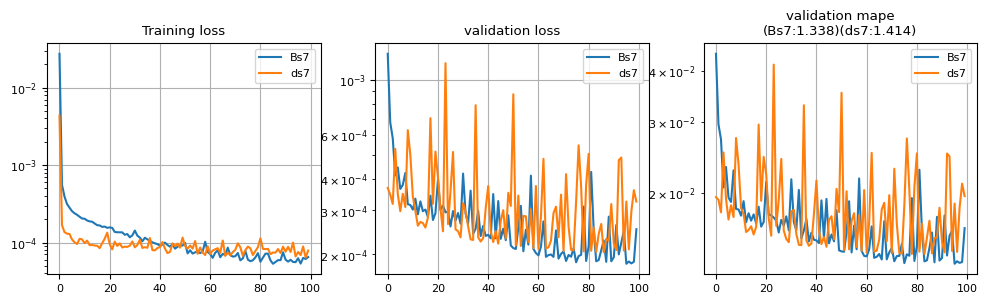

## 과제 4. Basic model에 Bidirectional Layer를 적용하고, 성능을 비교해 보자    
### 1) Bidrectionnal = True를 적용하자.  
### 2) whole_seq_output 을 사용하면 어떻게 될까? 결과를 검토 해보자     
### 3) LSTM, Dense 사이에 Flatten layer를 넣으면 어떻게 달라질까 생각해 보고, 결과도 확인하자  

In [ ]:
class BidirectionalModel(Wrap_regression):
    def __init__(self, input_features, hidden_dim):
        super().__init__()
        self.biLstm = nn.LSTM(input_features, hidden_dim,
                              bidirectional=True, ##
                              batch_first=True)
        self.linear = nn.Linear(hidden_dim*2, 1)  ##
        self.flatt_linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_dim*2*seq_length , 1)
        )

    def forward(self, x):
        x, _ = self.biLstm(x)
        x = self.linear(x[:, -1, :])
        return x

In [ ]:
model_Bi = BidirectionalModel(data_dim, hidden_dim)
summary(model_Bi, input_size=x_train[:batch_size].shape) #(64,7,5)

Layer (type:depth-idx)                   Output Shape              Param #
BidirectionalModel                       [64, 1]                   141
├─LSTM: 1-1                              [64, 7, 20]               1,360
├─Linear: 1-2                            [64, 1]                   21
Total params: 1,522
Trainable params: 1,522
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.61
Input size (MB): 0.01
Forward/backward pass size (MB): 0.07
Params size (MB): 0.01
Estimated Total Size (MB): 0.09

In [ ]:
%%time
model_Bi = BidirectionalModel(data_dim, hidden_dim)

name = "model_Bi"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_Bi, trainDataLoader, testDataLoader)
model_Bi.eval()

Wall time: 52.5 s


In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfBi = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["B","Bi"]
plt_history([df,dfBi],titles)

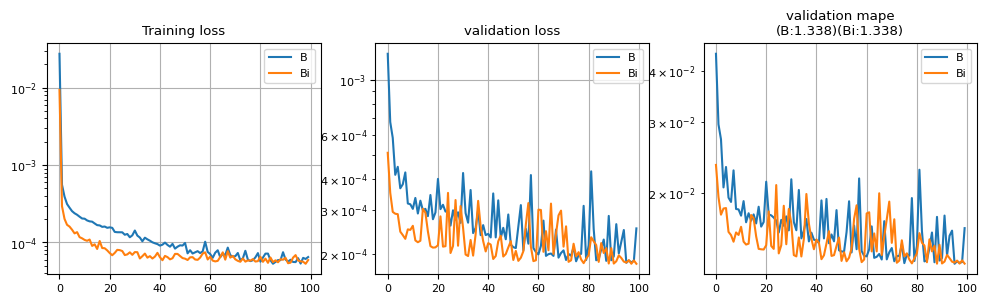

**Flatten Layer 사용**

In [ ]:
class BidirectionalModel(Wrap_regression):
    def __init__(self, input_features, hidden_dim):
        super().__init__()
        self.biLstm = nn.LSTM(input_features, hidden_dim,
                              bidirectional=True, ##
                              batch_first=True)
        self.flatt_linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_dim*2*seq_length , 1)
        )

    def forward(self, x): ## for whole_seq_out
        x, _ = self.biLstm(x)
        x = self.flatt_linear(x)
        return x

In [ ]:
model_Bi = BidirectionalModel(data_dim, hidden_dim)
summary(model_Bi, input_size=x_train[:batch_size].shape) #(64,7,5)

Layer (type:depth-idx)                   Output Shape              Param #
BidirectionalModel                       [64, 1]                   --
├─LSTM: 1-1                              [64, 7, 20]               1,360
├─Sequential: 1-2                        [64, 1]                   --
│    └─Flatten: 2-1                      [64, 140]                 --
│    └─Linear: 2-2                       [64, 1]                   141
Total params: 1,501
Trainable params: 1,501
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.62
Input size (MB): 0.01
Forward/backward pass size (MB): 0.07
Params size (MB): 0.01
Estimated Total Size (MB): 0.09

In [ ]:
%%time
model_Bi = BidirectionalModel(data_dim, hidden_dim)

name = "model_Bi"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_Bi, trainDataLoader, testDataLoader)
model_Bi.eval()

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfBi = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["B","BiF"]
plt_history([df,dfBi],titles)

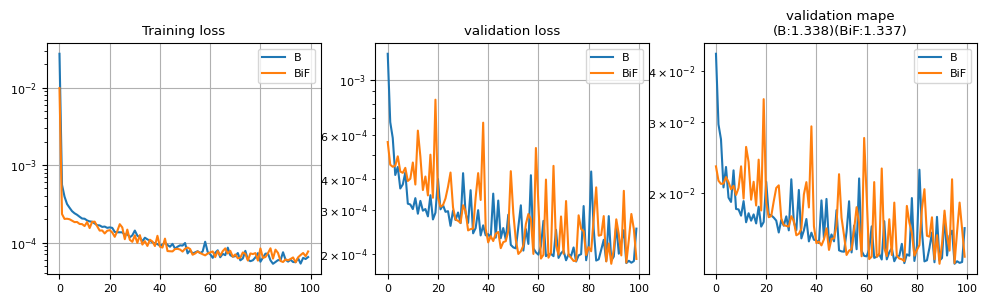

## 과제 5. 7일치 종가를 Target으로 하는 many to many model로 수정해 보자  
### - 과제 4에서 사용한 모델을 수정하자    

In [34]:
# sequence generator
def seq_gen_n(x,seq_length):
    dataX = []
    dataY = []
    for i in range(0, len(x) - seq_length):
        _x = x[i:i + seq_length] # 7일치 데이터
        _y = x[i+1:i+seq_length+1,3] # 다음날 종가 7일치

        dataX.append(_x)
        dataY.append(_y)
    # train data : test data = 9 : 1
    train_size = int(len(dataY) * 0.9)
    test_size  = len(dataY) - train_size
    x_train = np.array(dataX[0:train_size]).copy()
    y_train = np.array(dataY[0:train_size]).reshape(-1,seq_length,1)
    x_test  = np.array(dataX[train_size:])
    y_test  = np.array(dataY[train_size:]).reshape(-1,seq_length,1)
    return x_train,y_train,x_test,y_test

In [35]:
## x:7일치 데이터, y:8일차 종가
timesteps = seq_length = 7
x_train,y_train,x_test,y_test = seq_gen_n(XX,seq_length)

ps(x_train,'x_train')
ps(y_train,'y_train')
ps(x_test,'x_test')
ps(y_test,'y_test')

[x_train] Shape(2385, 7, 5)
[y_train] Shape(2385, 7, 1)
[x_test] Shape(266, 7, 5)
[y_test] Shape(266, 7, 1)


In [36]:
batch_size = 64

trainDataset = CustomDataset(x_train, y_train)
testDataset = CustomDataset(x_test, y_test)
trainDataLoader = DataLoader(trainDataset, batch_size, shuffle=True) # defalut : drop_last=False
testDataLoader = DataLoader(testDataset, batch_size, shuffle=False)

In [37]:
class Model_Bm(Wrap_regression):
    def __init__(self, input_features, hidden_dim):
        super().__init__()
        self.biLstm = nn.LSTM(input_features, hidden_dim,
                              bidirectional=True, ##
                              batch_first=True)
        self.linear = nn.Linear(hidden_dim*2, 1)  ##

    def forward(self, x):
        x, _ = self.biLstm(x)
        x = self.linear(x)                        ##
        return x

In [38]:
x_train[:batch_size].shape

(64, 7, 5)

In [ ]:
model_Bm = Model_Bm(data_dim, hidden_dim)
summary(model_Bm, input_size=x_train[:batch_size].shape) #(64,7,5)

Layer (type:depth-idx)                   Output Shape              Param #
Model_Bm                                 [64, 7, 1]                --
├─LSTM: 1-1                              [64, 7, 20]               1,360
├─Linear: 1-2                            [64, 7, 1]                21
Total params: 1,381
Trainable params: 1,381
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.61
Input size (MB): 0.01
Forward/backward pass size (MB): 0.08
Params size (MB): 0.01
Estimated Total Size (MB): 0.09

In [ ]:
%%time
model_Bm = Model_Bm(data_dim, hidden_dim)

name = "model_Bm"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_Bm, trainDataLoader, testDataLoader)
model_Bm.eval()

Wall time: 52.5 s


In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfBm = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["B","Bm"]
plt_history([df,dfBm],titles)

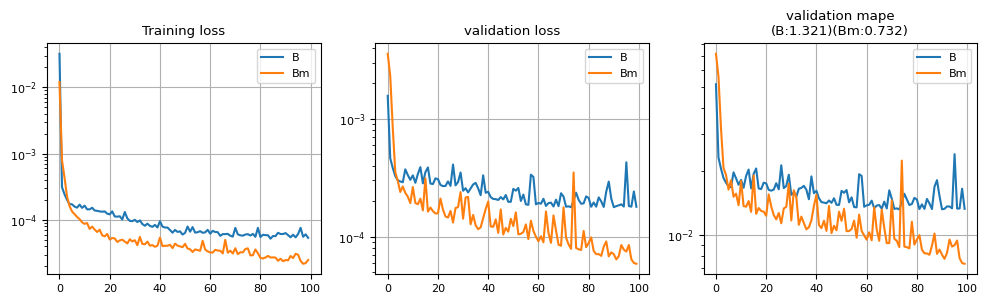

## 과제 6. 과제 5에서 Bidirectional layer를 stacking하고, 성능을 비교해 보자  

In [ ]:
class Model_BmS(Wrap_regression):
    def __init__(self, input_features, hidden_dim):
        super().__init__()
        self.biLstm = nn.LSTM(input_features, hidden_dim,
                              bidirectional=True, ##
                              num_layers=2,
                              batch_first=True)
        self.linear = nn.Linear(hidden_dim*2, 1)  ##

    def forward(self, x):
        x, _ = self.biLstm(x)
        x = self.linear(x)
        return x

In [ ]:
model_BmS = Model_BmS(data_dim, hidden_dim)
summary(model_BmS, input_size=x_train[:batch_size].shape) #(64,7,5)

Layer (type:depth-idx)                   Output Shape              Param #
Model_BmS                                [64, 7, 1]                --
├─LSTM: 1-1                              [64, 7, 20]               3,920
├─Linear: 1-2                            [64, 7, 1]                21
Total params: 3,941
Trainable params: 3,941
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.76
Input size (MB): 0.01
Forward/backward pass size (MB): 0.08
Params size (MB): 0.02
Estimated Total Size (MB): 0.10

In [ ]:
%%time
model_BmS = Model_BmS(data_dim, hidden_dim)

name = "model_BmS"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger)
trainer.fit(model_BmS, trainDataLoader, testDataLoader)
model_BmS.eval()

Wall time: 52.5 s


In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfBmS = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
titles=["B","Bm","BmS"]
plt_history([df,dfBm,dfBmS],titles)

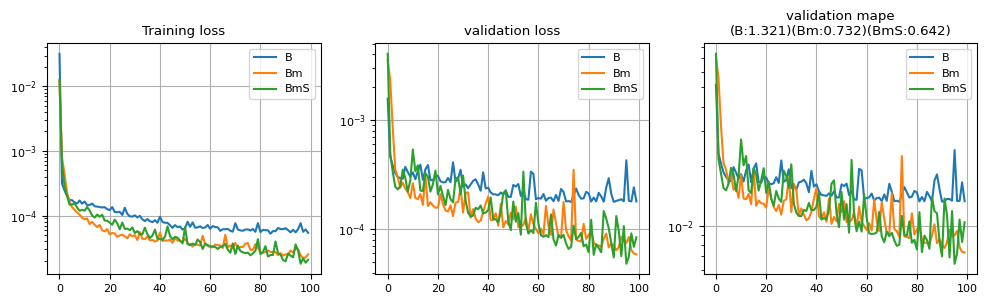